# Notebook 00 — Exploratory Data Analysis

## Requires
- `data/raw/training_setA/` and `data/raw/training_setB/` (raw .psv patient files)

## Produces
- `results/figures/missingness_by_feature.png`
- `results/figures/missingness_heatmap.png`
- `results/figures/class_distribution.png`
- `results/figures/icu_stay_distribution.png`
- `results/figures/time_to_sepsis.png`
- `results/figures/feature_distributions.png`
- `results/figures/vital_trajectories_sepsis_vs_not.png`
- `results/figures/feature_correlation_matrix.png`
- `results/metrics/integrity_report.txt`

## Run Order
Run this **FIRST** — before any preprocessing or modelling.

In [1]:
import sys
from pathlib import Path

# Locate project root — works whether kernel CWD is project root or notebooks/
_here = Path.cwd()
if (_here / 'src').exists():
    _root = _here            # already at project root
elif (_here.parent / 'src').exists():
    _root = _here.parent     # one level up (e.g. running from notebooks/)
else:
    _root = _here            # fallback (Colab: setup cell above should handle this)

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RANDOM_SEED, DATA_DIR, FIGURES_DIR, METRICS_DIR,
    ALL_FEATURES, VITAL_SIGNS, LAB_VALUES, DEMOGRAPHICS
)

np.random.seed(RANDOM_SEED)
Path(_root / FIGURES_DIR).mkdir(parents=True, exist_ok=True)
Path(_root / METRICS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Project root : {_root}')
print('Imports OK')

Project root : /Users/user/Desktop/ML_Final Project/Sepsis_ML_Prediction
Imports OK


## Step 1 — Load All Patients

Reads every `.psv` file from Set A and Set B into a single DataFrame with a `patient_id` column. Takes ~2–3 minutes for 40,336 files.

In [3]:
from tqdm import tqdm

SET_A_DIR = _root / 'data' / 'raw' / 'training_setA'
SET_B_DIR = _root / 'data' / 'raw' / 'training_setB'

def load_all_patients():
    """Load all .psv files into one DataFrame with a patient_id column."""
    all_files = sorted(SET_A_DIR.glob('*.psv')) + sorted(SET_B_DIR.glob('*.psv'))

    if not all_files:
        raise FileNotFoundError(
            f"No .psv files found in:\n  {SET_A_DIR}\n  {SET_B_DIR}\n\n"
            "Locally: run 'python3 src/download_data.py' from the project root."
        )

    dfs = []
    for f in tqdm(all_files, desc='Loading patients'):
        d = pd.read_csv(f, sep='|')
        d['patient_id'] = f.stem
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

df = load_all_patients()
print(f'Loaded {df["patient_id"].nunique():,} patients  |  {len(df):,} total rows')

Loading patients: 100%|██████████| 40336/40336 [02:04<00:00, 322.97it/s]


Loaded 40,336 patients  |  1,552,210 total rows


## Step 2 — Missingness Analysis (Issue #7)

### 2a — % Missing Per Feature

Lab values are drawn on clinical demand, not on a fixed clock. We expect vitals to have low missingness and rare labs (lactate, troponin) to have >90% missing.

Feature Missingness (%):
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP            

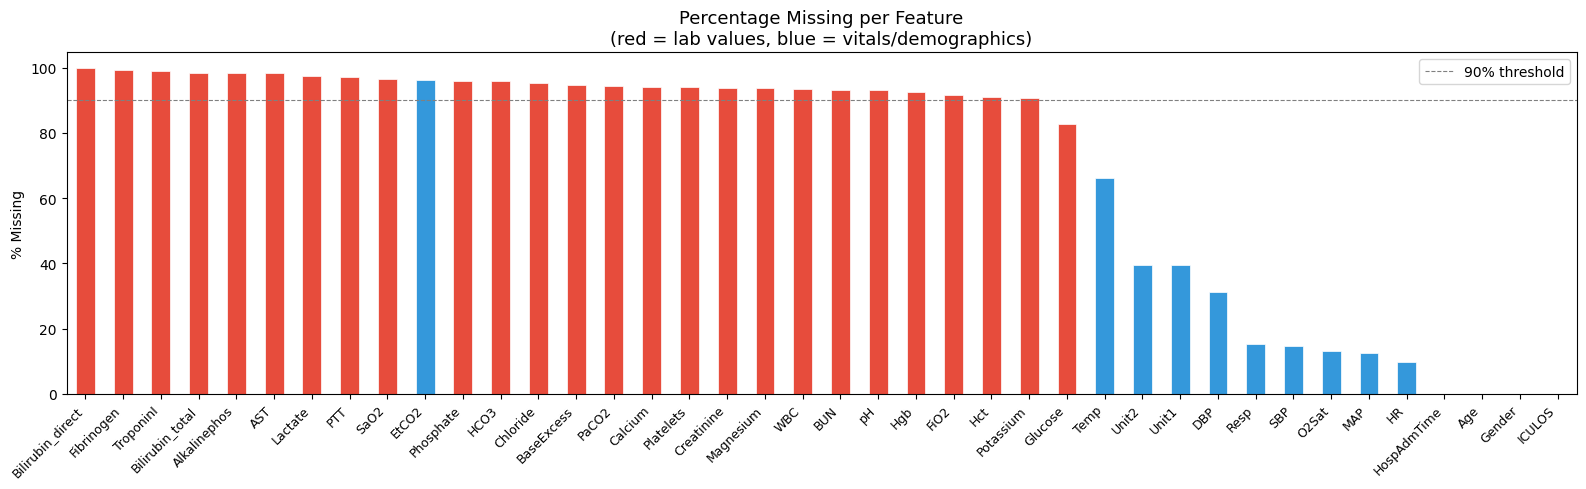

Saved → results/figures/missingness_by_feature.png


In [4]:
missing_pct = df[ALL_FEATURES].isna().mean().sort_values(ascending=False) * 100

print("Feature Missingness (%):")
print(missing_pct.to_string())

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#e74c3c' if f in LAB_VALUES else '#3498db' for f in missing_pct.index]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Percentage Missing per Feature\n(red = lab values, blue = vitals/demographics)', fontsize=13)
ax.set_ylabel('% Missing')
ax.set_xlabel('')
ax.axhline(90, color='grey', linestyle='--', linewidth=0.8, label='90% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'missingness_by_feature.png', dpi=150)
plt.show()
print("Saved → results/figures/missingness_by_feature.png")

### 2b — Missingness Heatmap (Patients × Time)

Shows which timesteps actually have lab measurements for a sample of 200 patients. Each row is a patient; each column is an ICU hour.

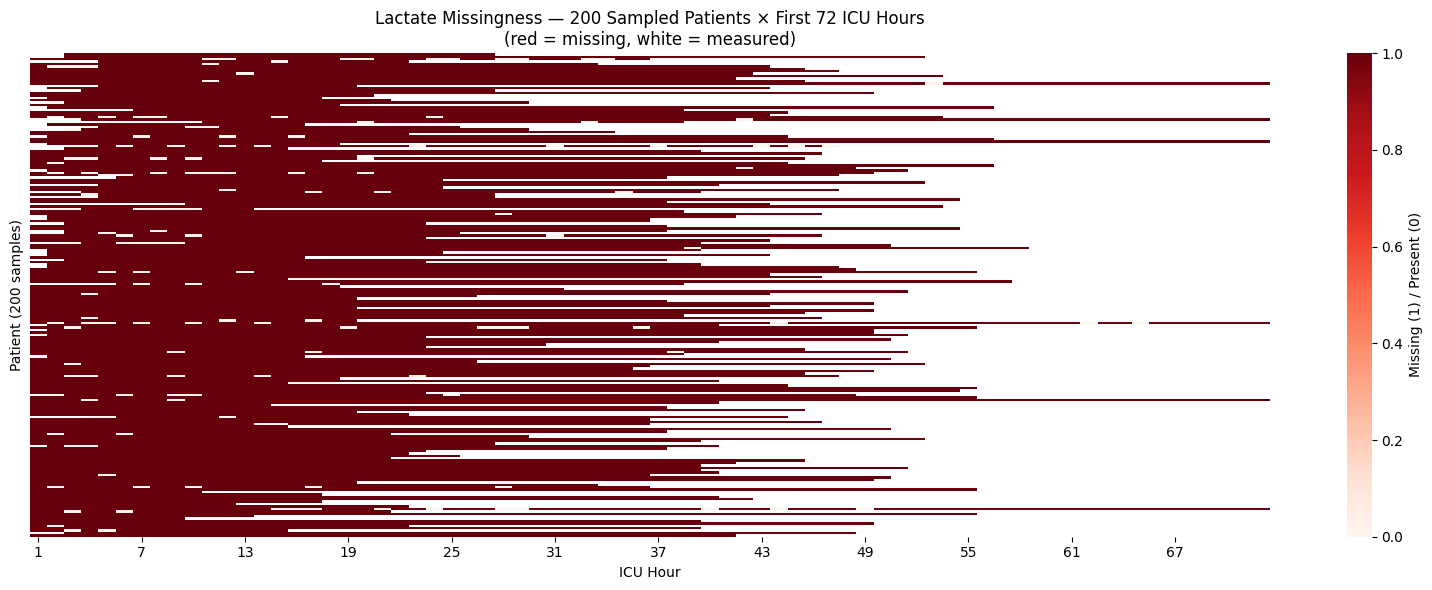

Saved → results/figures/missingness_heatmap.png


In [5]:
np.random.seed(RANDOM_SEED)
sample_ids = np.random.choice(df['patient_id'].unique(), size=200, replace=False)
sample_df  = df[df['patient_id'].isin(sample_ids)].copy()

# Focus on Lactate — highest clinical relevance, highest missingness
pivot = sample_df.pivot_table(
    index='patient_id', columns='ICULOS',
    values='Lactate', aggfunc=lambda x: float(x.isna().all())
)
# Trim to first 72h (our MAX_SEQ_LEN)
pivot = pivot[[c for c in pivot.columns if c <= 72]]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='Reds', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=ax, xticklabels=6, yticklabels=False)
ax.set_title('Lactate Missingness — 200 Sampled Patients × First 72 ICU Hours\n'
             '(red = missing, white = measured)', fontsize=12)
ax.set_xlabel('ICU Hour')
ax.set_ylabel('Patient (200 samples)')
plt.tight_layout()
plt.savefig(_root / FIGURES_DIR / 'missingness_heatmap.png', dpi=150)
plt.show()
print("Saved → results/figures/missingness_heatmap.png")

### 2c — Is Missingness Informative? (MNAR Test)

For each lab value, compare the missingness rate between sepsis and non-sepsis patients. If the rates differ significantly, missingness is **not random** — it is clinically driven (Missing Not At Random). This directly validates Strategy B.

In [6]:
# Patient-level labels: 1 if SepsisLabel ever = 1, else 0
patient_labels = df.groupby('patient_id')['SepsisLabel'].max().reset_index()
patient_labels.columns = ['patient_id', 'is_sepsis']

sepsis_ids     = set(patient_labels[patient_labels['is_sepsis'] == 1]['patient_id'])
non_sepsis_ids = set(patient_labels[patient_labels['is_sepsis'] == 0]['patient_id'])

df_sep     = df[df['patient_id'].isin(sepsis_ids)]
df_non_sep = df[df['patient_id'].isin(non_sepsis_ids)]

mnar_rows = []
for feat in LAB_VALUES:
    sep_miss     = df_sep[feat].isna().mean() * 100
    non_sep_miss = df_non_sep[feat].isna().mean() * 100
    diff         = sep_miss - non_sep_miss
    mnar_rows.append({
        'feature':              feat,
        'sepsis_missing_%':     round(sep_miss, 1),
        'non_sepsis_missing_%': round(non_sep_miss, 1),
        'difference_%':         round(diff, 1),
    })

mnar_df = (pd.DataFrame(mnar_rows)
             .sort_values('difference_%', key=abs, ascending=False)
             .reset_index(drop=True))

print(f"Sepsis patients    : {len(sepsis_ids):,}")
print(f"Non-sepsis patients: {len(non_sepsis_ids):,}")
print(f"\nMNAR Comparison (sorted by |difference|):")
print(mnar_df.to_string(index=False))

mnar_df.to_csv(_root / METRICS_DIR / 'mnar_comparison.csv', index=False)
print(f"\nSaved → results/metrics/mnar_comparison.csv")

Sepsis patients    : 2,932
Non-sepsis patients: 37,404

MNAR Comparison (sorted by |difference|):
         feature  sepsis_missing_%  non_sepsis_missing_%  difference_%
            FiO2              83.3                  92.7          -9.5
              pH              88.9                  93.6          -4.7
           PaCO2              90.8                  94.9          -4.1
      BaseExcess              91.1                  95.0          -3.9
         Lactate              94.6                  97.7          -3.0
       Potassium              88.4                  91.0          -2.5
        Chloride              93.6                  95.7          -2.1
       Magnesium              92.0                  93.9          -1.9
            HCO3              94.2                  96.0          -1.8
         Calcium              92.6                  94.3          -1.7
       Phosphate              94.6                  96.2          -1.6
            SaO2              95.1                

### 2d — Conclusion: Is Missingness MNAR?

**Yes — lab missingness is Missing Not At Random (MNAR).**

Across all 26 lab values, sepsis patients have consistently *lower* missingness rates than non-sepsis patients. The largest differences are in FiO2 (−9.5%), pH (−4.7%), PaCO2 (−4.1%), and Lactate (−3.0%). This is exactly what clinical practice predicts: clinicians order arterial blood gas panels (pH, PaCO2, FiO2, BaseExcess) and lactate draws precisely when a patient shows signs of deterioration or suspected sepsis. A measurement being present is itself a signal of clinical concern.

Strategy A (median imputation) treats every missing value as noise and discards this signal. Strategy B (forward-fill + missingness indicator columns) preserves it with binary flags that tell the model *when* each lab was measured. If Strategy B outperforms Strategy A in our 2×2 experiment, this MNAR analysis provides the mechanistic justification.